## Import Needed Liberary

In [4]:
df.cell()
df.info()
df.described()



AttributeError: 'DataFrame' object has no attribute 'cell'

In [ ]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

**Data Representation**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


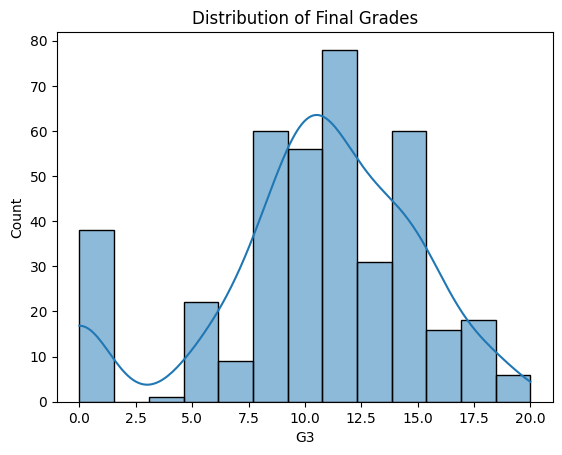

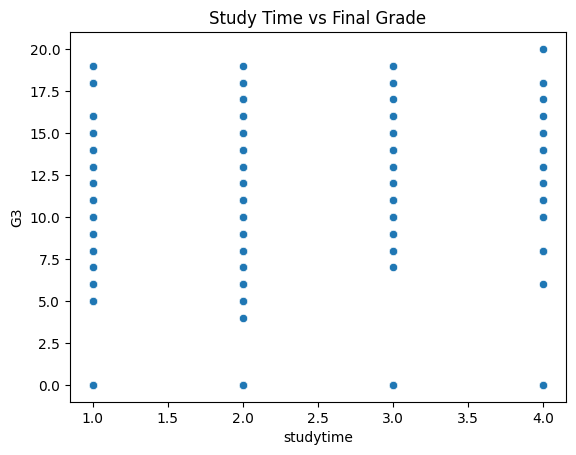

Model Accuracy: 0.21067380590414997


In [11]:
import pandas as pd 
df=pd.read_csv("/kaggle/input/student-performance-data/student_data.csv")
df.head()
df.info()
df.describe()
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of final grades
sns.histplot(df['G3'], kde=True)
plt.title("Distribution of Final Grades")
plt.show()
sns.scatterplot(x='studytime', y='G3', data=df)
plt.title("Study Time vs Final Grade")
plt.show()
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['studytime', 'failures', 'absences']]
y = df['G3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Accuracy:", model.score(X_test, y_test))

In [ ]:
df.head(10)

In [ ]:
df.tail()

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.describe(include="O")

**Handle Duplicate values**

In [ ]:
df.duplicated().sum()

In [ ]:
df.isnull().sum()

# Aggregating Absences Data in a DataFrame 

In [ ]:
df["absences"].agg(["max" , "min" , "mean"])

In [ ]:
df['Avg Score']= ((df['G1']+df['G2']+df['G3'])/3)
df

In [ ]:
df["Performance Category"] = pd.qcut(df["Avg Score"] , q=3 , labels=["Low" , "Medium" , "High"])
df

In [ ]:
pivot=df.pivot_table(index='Mjob',values='Avg Score',aggfunc='mean')
pivot

In [ ]:
pivot=df.pivot_table(index='Fjob',values='Avg Score',aggfunc='mean')
pivot

In [ ]:
pivot=df.pivot_table(index='Pstatus',values='Avg Score',aggfunc='mean')
pivot

In [ ]:
pivot=df.pivot_table(index='internet',values='Avg Score',aggfunc='mean')
pivot

In [ ]:
pivot=df.pivot_table(index='higher',values='Avg Score',aggfunc='mean')
pivot

In [ ]:
pivot=df.pivot_table(index='school',values='failures',aggfunc='mean')
pivot

In [ ]:
pivot=df.pivot_table(index='school',values='Avg Score',aggfunc='mean')
pivot

In [ ]:
df[df["famsize"].isin(["GT3"])]

# univariate analysis

In [ ]:
mj =df['Mjob'].value_counts()
mj

In [ ]:
plt.bar(mj.index ,mj.values ,color ='purple' )
plt.title('Mjob Distribution')
plt.xlabel('Mjob')
plt.ylabel('count')

In [ ]:
colors = plt.cm.tab10.colors[:len(mj)]  

plt.pie(x=mj, labels=mj.index, autopct="%0.0f%%", shadow=True, colors=colors)
plt.title('Mjob')
plt.legend(loc=1)  
plt.show()

In [ ]:
df

In [ ]:
Fjob=df['Fjob'].value_counts()
Fjob

In [ ]:
plt.bar(mj.index ,mj.values ,color ='purple' )
plt.title('Fjob Distribution')
plt.xlabel('Fjob')
plt.ylabel('count')

In [ ]:
plt.pie(x=Fjob ,labels=Fjob.index ,autopct='%0.0f%%' ,shadow=True,explode=[0,0,0,0.3,0.2])
plt.title('Fjob distribution')
plt.legend(loc=1)

In [ ]:
df

In [ ]:
school=df['school'].value_counts()
school

In [ ]:
plt.bar(school.index ,school.values ,color ='purple' )
plt.title('school Distribution')
plt.xlabel('school')
plt.ylabel('count')

In [ ]:
plt.pie(x=school ,labels=school.index ,autopct='%0.0f%%' ,shadow=True,explode=[0.3,0.2])
plt.title('Fjob distribution')
plt.legend(loc=1)

In [ ]:
df["absences"].agg(["min", "max", "mean"])

In [ ]:
df[df["absences"] == 75.000000]

In [ ]:
df[df["absences"]==0.000000]

In [ ]:
absences=df['absences'].value_counts()
absences

In [ ]:
plt.bar(absences.index ,absences.values ,color ='purple' )
plt.title('absences Distribution')
plt.xlabel('absences')
plt.ylabel('count')

In [ ]:

absences = absences.sort_values(ascending=False)


threshold = absences.sum() * 0.03  
absences_filtered = absences[absences >= threshold]
other_sum = absences[absences < threshold].sum()
if other_sum > 0:
    absences_filtered["Other"] = other_sum 


explode = [0.1 if i < 3 else 0 for i in range(len(absences_filtered))]


colors = plt.cm.get_cmap("tab20").colors[:len(absences_filtered)]


plt.figure(figsize=(12, 12))


wedges, texts, autotexts = plt.pie(
    absences_filtered, 
    labels=absences_filtered.index, 
    autopct='%0.1f%%', 
    shadow=True, 
    colors=colors, 
    startangle=140, 
    pctdistance=0.6,  
    labeldistance=1.1, 
    explode=explode  
)


for text in texts:
    text.set_fontsize(14)  
for autotext in autotexts:
    autotext.set_fontsize(14)  


plt.title('Absences Distribution', fontsize=18)


plt.legend(wedges, absences_filtered.index, title="Categories", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12)

plt.show()


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(8, 15))
    values = df[col].value_counts() 
    plt.pie(values, labels=values.index, autopct='%.1f%%', shadow=False)
    plt.title(f'{col} students')
    plt.show()